In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

In [2]:
os.chdir(r"C:\Users\bhuva\OneDrive\Documents\social media")

print(os.listdir())

['addiction_risk_model.pkl', 'app.py', 'ddd.txt', 'label_encoder.pkl', 'label_encoders.pkl', 'ls usrlocal.txt', 'social_media_productivity_6000 (1).csv', 'Teen_Mental_Health_Dataset (1).csv', 'Twitter_Data (1).csv']


In [3]:
df = pd.read_csv("social_media_productivity_6000 (1).csv")

df.head()

,age,daily_screen_time,social_media_hours,study_hours,sleep_hours,notifications_per_day,focus_score,addiction_level,productivity_score
0,21.0,5.95,2.81,2.61,6.99,283.0,100.00,Medium,28.49
1,34.0,3.82,2.33,0.28,7.47,266.0,93.65,Medium,18.54
2,29.0,3.57,1.64,5.21,6.34,137.0,100.00,Low,68.52
3,25.0,10.27,4.37,4.28,4.49,247.0,94.71,Medium,27.82
4,22.0,2.42,1.60,3.67,6.34,28.0,100.00,Low,51.09


In [4]:
print(df.shape)

(6000, 9)


In [5]:
print(df.columns)

Index(['age', 'daily_screen_time', 'social_media_hours', 'study_hours',
       'sleep_hours', 'notifications_per_day', 'focus_score',
       'addiction_level', 'productivity_score'],
      dtype='str')


In [6]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   age                    5880 non-null   float64
 1   daily_screen_time      5880 non-null   float64
 2   social_media_hours     5880 non-null   float64
 3   study_hours            5880 non-null   float64
 4   sleep_hours            5880 non-null   float64
 5   notifications_per_day  5880 non-null   float64
 6   focus_score            5880 non-null   float64
 7   addiction_level        5880 non-null   str    
 8   productivity_score     5880 non-null   float64
dtypes: float64(8), str(1)
memory usage: 450.8 KB
None


In [7]:
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)

print("After cleaning:", df.shape)
print(df.isnull().sum())

After cleaning: (4999, 9)
age                      0
daily_screen_time        0
social_media_hours       0
study_hours              0
sleep_hours              0
notifications_per_day    0
focus_score              0
addiction_level          0
productivity_score       0
dtype: int64


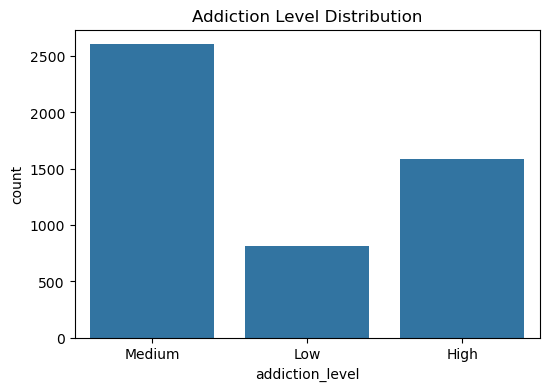

In [8]:
plt.figure(figsize=(6,4))
sns.countplot(x=df["addiction_level"])
plt.title("Addiction Level Distribution")
plt.show()

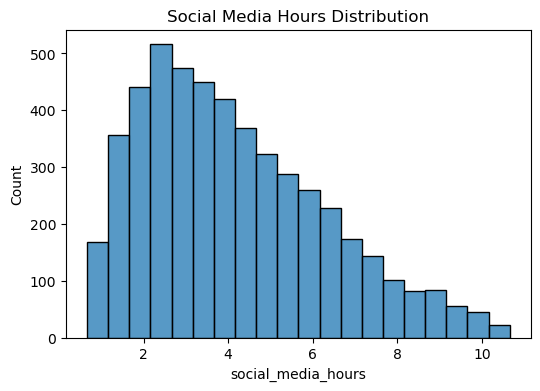

In [9]:
plt.figure(figsize=(6,4))
sns.histplot(df["social_media_hours"], bins=20)
plt.title("Social Media Hours Distribution")
plt.show()

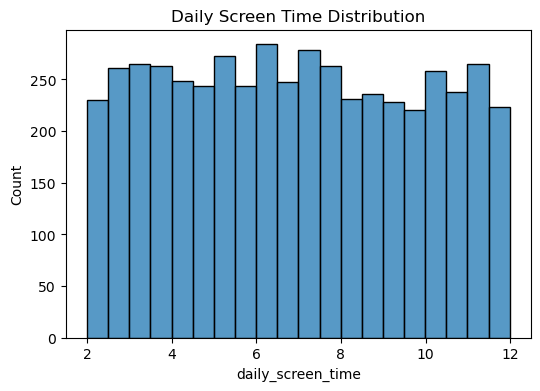

In [10]:
plt.figure(figsize=(6,4))
sns.histplot(df["daily_screen_time"], bins=20)
plt.title("Daily Screen Time Distribution")
plt.show()

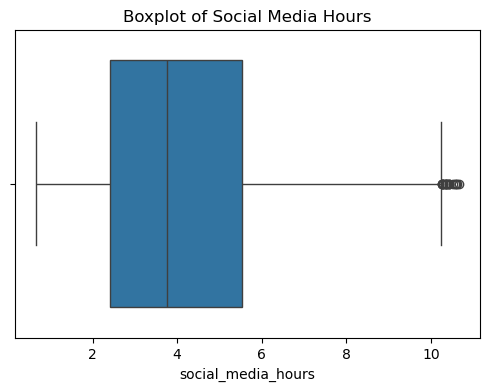

In [11]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df["social_media_hours"])
plt.title("Boxplot of Social Media Hours")
plt.show()

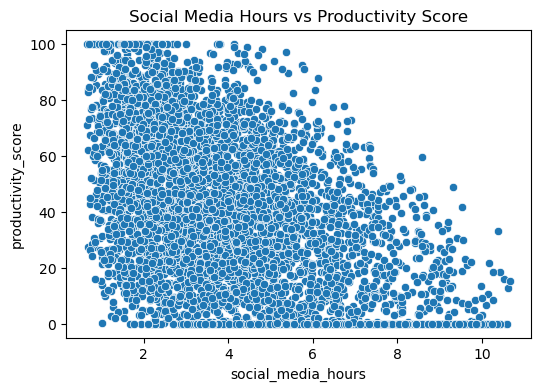

In [12]:
plt.figure(figsize=(6,4))
sns.scatterplot(x=df["social_media_hours"], y=df["productivity_score"])
plt.title("Social Media Hours vs Productivity Score")
plt.show()

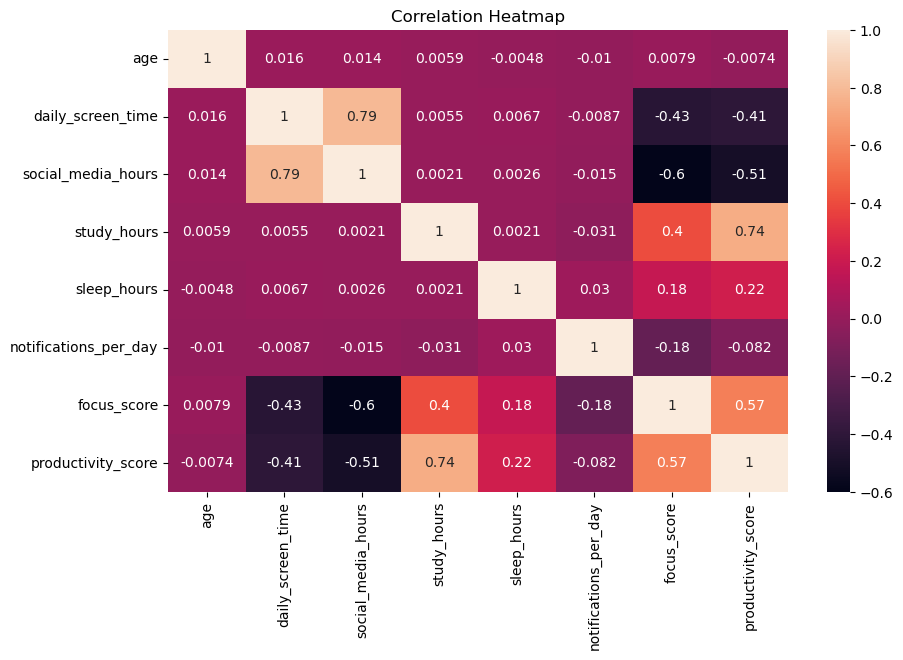

In [13]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Heatmap")
plt.show()

In [14]:
X = df.drop("addiction_level", axis=1)

le = LabelEncoder()
y = le.fit_transform(df["addiction_level"])

print("Classes:", le.classes_)
print(X.head())

Classes: ['High' 'Low' 'Medium']
    age  daily_screen_time  social_media_hours  study_hours  sleep_hours  \
0  21.0               5.95                2.81         2.61         6.99   
1  34.0               3.82                2.33         0.28         7.47   
2  29.0               3.57                1.64         5.21         6.34   
3  25.0              10.27                4.37         4.28         4.49   
4  22.0               2.42                1.60         3.67         6.34   

   notifications_per_day  focus_score  productivity_score  
0                  283.0       100.00               28.49  
1                  266.0        93.65               18.54  
2                  137.0       100.00               68.52  
3                  247.0        94.71               27.82  
4                   28.0       100.00               51.09  


In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [16]:
models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "SVM": SVC(kernel="rbf", C=10)
}

results = []

best_model = None
best_accuracy = 0
best_name = ""

for name, model in models.items():
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average="weighted", zero_division=0)
    recall = recall_score(y_test, y_pred, average="weighted", zero_division=0)
    f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)

    results.append([name, accuracy, precision, recall, f1])

    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_model = model
        best_name = name

results_df = pd.DataFrame(
    results,
    columns=["Algorithm", "Accuracy", "Precision", "Recall", "F1 Score"]
)

results_df

,Algorithm,Accuracy,Precision,Recall,F1 Score
0,Decision Tree,1.000,1.000000,1.000,1.000000
1,Random Forest,1.000,1.000000,1.000,1.000000
2,Gradient Boosting,1.000,1.000000,1.000,1.000000
3,SVM,0.856,0.860337,0.856,0.851724


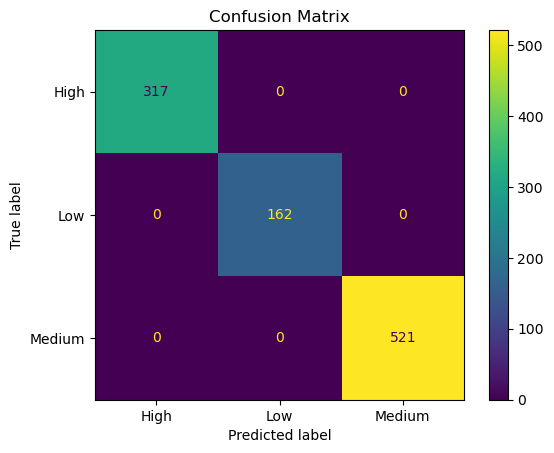

In [17]:
y_pred = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=le.classes_
)

disp.plot()
plt.title("Confusion Matrix")
plt.show()